In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [97]:
# Reading CSV file into DataFrame
df = pd.read_csv('/Users/alanphan/Documents/WGU MSDA/Course Materials/D600/Task 1/data/D600 Task 1 Dataset 1 Housing Information.csv')
df

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,4922,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,...,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,5009,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,...,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,4450,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,...,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,1070,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,...,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,400,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,...,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,6987,307821.1758,550.00,2.111022,4,892.35,11.89,7.97,28.18,19.23,...,4.76,3.81,6.87,No,White,Yes,1,18,241131.63070,1
6996,6995,421368.8869,1726.12,4.056115,2,943.19,34.06,5.82,90.45,17.60,...,5.31,9.84,10.00,No,White,Yes,1,18,481604.80730,1
6997,6996,473382.5348,1026.36,2.077177,5,149.31,0.10,8.81,31.79,11.59,...,4.98,7.47,2.96,No,Green,No,1,13,380555.49390,1
6998,6998,343397.9756,2218.22,1.000000,4,526.81,11.18,9.20,15.21,3.96,...,4.68,7.66,6.12,No,Blue,Yes,1,10,442610.31710,0


In [98]:
# Selecting independent and dependent variables
variables = ['Price', 'CrimeRate', 'SchoolRating']
df = df[variables]
df

,Price,CrimeRate,SchoolRating
0,255614.8992,20.56,5.62
1,155586.0947,15.62,5.63
2,131050.8324,12.47,9.20
3,151361.7125,22.22,7.08
4,113167.6128,8.28,5.93
...,...,...,...
6995,307821.1758,11.89,7.97
6996,421368.8869,34.06,5.82
6997,473382.5348,0.10,8.81
6998,343397.9756,11.18,9.20


In [99]:
# Descriptive statistics
df.describe()

,Price,CrimeRate,SchoolRating
count,7.000000e+03,7000.000000,7000.000000
mean,3.072820e+05,31.226194,6.942923
std,1.501734e+05,18.025327,1.888148
min,8.500000e+04,0.030000,0.220000
25%,1.921075e+05,17.390000,5.650000
50%,2.793230e+05,30.385000,7.010000
75%,3.918781e+05,43.670000,8.360000
max,1.046676e+06,99.730000,10.000000


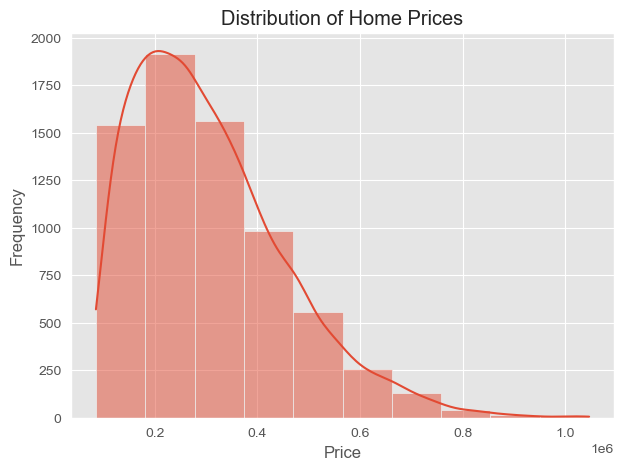

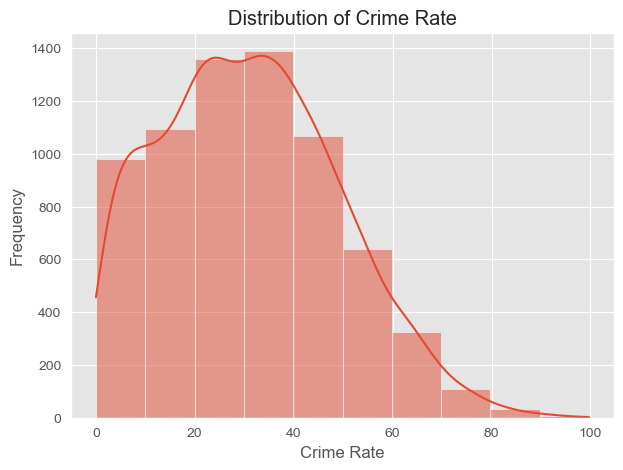

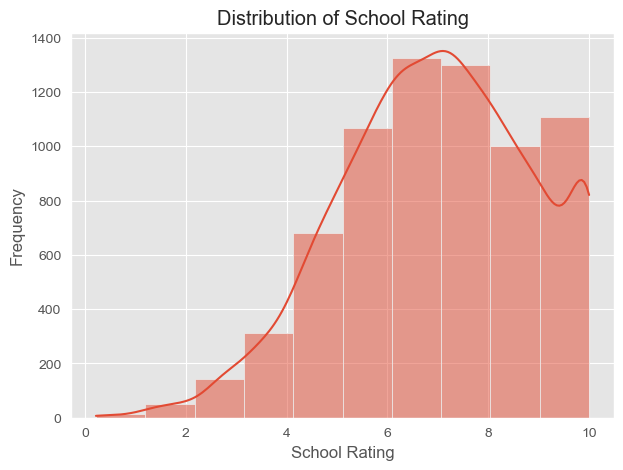

In [100]:
# Univariate visualizations of the variables
# Histogram of the dependent variable price
plt.figure(figsize = (7, 5))
sns.histplot(df['Price'], kde = True, bins = 10)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Home Prices')

# Histogram of the independent variable CrimeRate
plt.figure(figsize = (7, 5))
sns.histplot(df['CrimeRate'], kde = True, bins = 10)
plt.xlabel('Crime Rate')
plt.ylabel('Frequency')
plt.title('Distribution of Crime Rate')

# Histogram of the independent variable SchoolRating
plt.figure(figsize = (7, 5))
sns.histplot(df['SchoolRating'], kde = True, bins = 10)
plt.xlabel('School Rating')
plt.ylabel('Frequency')
plt.title('Distribution of School Rating');

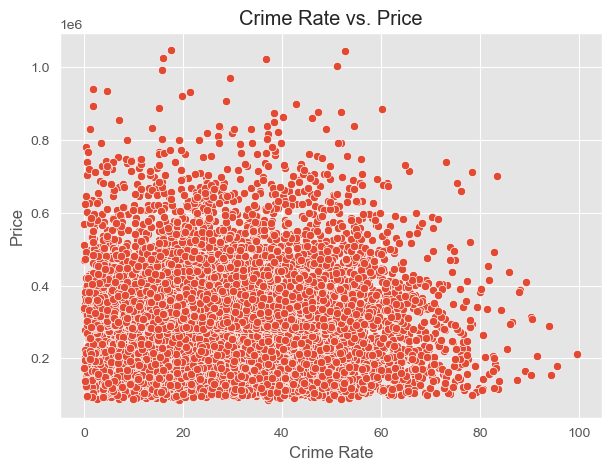

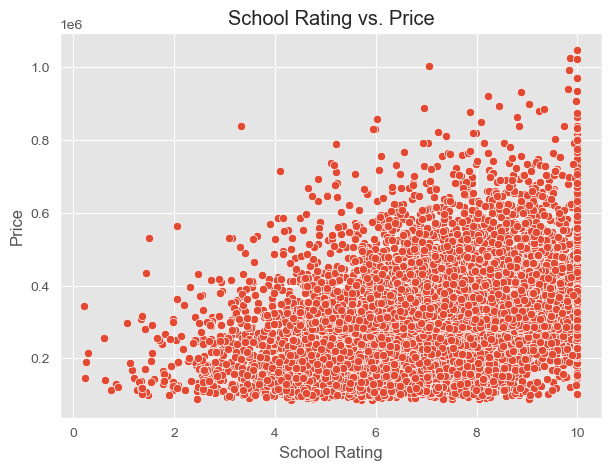

In [101]:
# Bivariate visualizations of each independent variable with the dependent variable
# Scatterplot of CrimeRate vs. Price
plt.figure(figsize = (7, 5))
sns.scatterplot(data = df, x = 'CrimeRate', y = 'Price')
plt.title('Crime Rate vs. Price')
plt.xlabel('Crime Rate')

# Scatterplot of SchoolRating vs. Price
plt.figure(figsize = (7, 5))
sns.scatterplot(data = df, x = 'SchoolRating', y = 'Price')
plt.title('School Rating vs. Price')
plt.xlabel('School Rating');

In [102]:
# Splitting the data 80/20 into training and test datasets to avoid any data leakage
train_df, test_df = train_test_split(df, test_size = 0.2, random_state = 42)

# Shapes of the two datasets
print(f"Training dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")

Training dataset shape: (5600, 3)
Test dataset shape: (1400, 3)


In [103]:
# Saving the two datasets as CSV files
train_df.to_csv('Training Dataset.csv', index = False)
test_df.to_csv('Test Dataset.csv', index = False)

In [104]:
# Creating X_train, y_train, X_test, and y_test
X_train = train_df.drop('Price', axis = 1)
y_train = train_df['Price']
X_test = test_df.drop('Price', axis = 1)
y_test = test_df['Price']

# Shapes of X_train, y_train, X_test, and y_test
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5600, 2)
y_train shape: (5600,)
X_test shape: (1400, 2)
y_test shape: (1400,)


In [105]:
# Adding a constant (required for statsmodels)
X_train = sm.add_constant(X_train)

# Calculating VIF values
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

vif_data.index = vif_data.index + 1 # Make the index start at 1 instead of 0
vif_data

,Feature,VIF
1,const,20.517155
2,CrimeRate,1.036409
3,SchoolRating,1.036409


In [106]:
# Initial linear regression
model = sm.OLS(y_train, X_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     493.3
Date:                Wed, 26 Mar 2025   Prob (F-statistic):          4.94e-198
Time:                        22:24:27   Log-Likelihood:                -74283.
No. Observations:                5600   AIC:                         1.486e+05
Df Residuals:                    5597   BIC:                         1.486e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         8.869e+04   8446.495     10.500      0.000    7.21e+04    1.05e+05
CrimeRate      103.9945    105.146      0.989      0.323    -102.133     310.122
SchoolRating  3.121e+04   1005.990     31.023      0.000    2.92e+04    3.32e+04
==============================================================================
Omnibus:                      721.381   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1090.969
Skew:                           0.931   Prob(JB):                    1.26e-237
Kurtosis:                       4.099   Cond. No.                         167.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [107]:
# Backward stepwise elimination
# Function will take in X and y
def backward_elimination(X, y, significance_level = 0.05):
    while True:
        model = sm.OLS(y, X).fit() # Fit the regression model
        p_values = model.pvalues.drop('const') # Get the p-values of the model and ignore the 'const'
        max_p_value = p_values.max() # Find the max p-value
        # If the max p-value is > than 0.05, drop the column (idxmax() returns the index of the highest p-value, which is the column name to drop from X) and continue the loop
        if max_p_value > significance_level:
            feature_to_drop = p_values.idxmax()
            print(f"Dropping {feature_to_drop} (p-value: {max_p_value:.4f})")
            X = X.drop(feature_to_drop, axis = 1)
        else:
            break # If max p-value is < 0.05, end the loop
    return model, X.columns.to_list()

# Creating optimized model using the backward_elimination function
optimized_model, selected_features = backward_elimination(X_train, y_train)
optimized_model.summary()

Dropping CrimeRate (p-value: 0.3227)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     985.6
Date:                Wed, 26 Mar 2025   Prob (F-statistic):          2.04e-199
Time:                        22:26:05   Log-Likelihood:                -74283.
No. Observations:                5600   AIC:                         1.486e+05
Df Residuals:                    5598   BIC:                         1.486e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         9.323e+04   7089.265     13.150      0.000    7.93e+04    1.07e+05
SchoolRating  3.102e+04    988.160     31.394      0.000    2.91e+04     3.3e+04
==============================================================================
Omnibus:                      722.289   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1093.015
Skew:                           0.932   Prob(JB):                    4.52e-238
Kurtosis:                       4.101   Cond. No.                         27.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [108]:
# MSE of the optimized model used on the training dataset
# Capturing only the features that remained
X_train_final = X_train[selected_features]

y_train_pred = optimized_model.predict(X_train_final)
mse_train = mean_squared_error(y_train, y_train_pred)
print(f"Training MSE: {mse_train}")

Training MSE: 19465568630.58456


In [109]:
# Running the prediction on the test dataset using the optimized regression model
# Adding constant
X_test = sm.add_constant(X_test)

# Keeping only the features used in the optimized model
X_test_final = X_test[['const', 'SchoolRating']]

# Making predictions on the test set
y_test_pred = optimized_model.predict(X_test_final)

# Calculating the test MSE
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Test MSE: {mse_test}")

Test MSE: 18049936441.202656


In [110]:
# Actual Price vs. Predicted Price
actual_vs_predicted = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_test_pred, 'Difference': y_test - y_test_pred})
actual_vs_predicted

,Actual Price,Predicted Price,Difference
6500,588317.6568,356604.521709,231713.135091
2944,104021.6679,245855.808799,-141834.140899
2024,185708.2598,316586.079229,-130877.819429
263,128945.4664,265399.699312,-136454.232912
4350,343116.7513,265089.478828,78027.272472
...,...,...,...
3484,122075.1750,317516.740682,-195441.565682
1860,145554.5086,306659.023730,-161104.515130
4974,301419.9178,238410.517175,63009.400625
387,216663.4381,254541.982360,-37878.544260


In [111]:
# Test RMSE
rmse_test = np.sqrt(mse_test)
print(f"Test RMSE: {rmse_test}")

Test RMSE: 134350.05188388523


In [112]:
# Training RMSE
rmse_train = np.sqrt(mse_train)
print(f"Training RMSE: {rmse_train}")

Training RMSE: 139519.06188970938


In [113]:
# Difference between the training and test RMSEs
rmse_train - rmse_test

5169.010005824151

In [114]:
# Predicting a home price with a school rating
# Including the constant term
new_data = pd.DataFrame({'const': [1], 'SchoolRating': [8]})

# Using the optimized model to make a prediction
predicted_price = optimized_model.predict(new_data)
print(f"Predicted price for a home with school rating 8: ${predicted_price[0]:,.2f}")

Predicted price for a home with school rating 8: $341,403.72
